In [31]:
 #NOTEBOOK 5 : MODÈLES BASÉS SUR LES ARBRES 
#🎯 Objectif
#Entraîner et optimiser des modèles basés sur les arbres de décision avec les données préparées du Notebook 3.

# Imports standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import joblib
from time import time
import warnings
import os
import optuna

warnings.filterwarnings('ignore')

# Configuration
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Imports réussis !")

✅ Imports réussis !


In [32]:
print("\n" + "="*80)
print("📋 CHARGEMENT DES DONNÉES PRÉPARÉES")
print("="*80)

try:
    # Charger les données du Notebook 3
    X_train = pd.read_csv('../data/processed/X_train.csv')
    X_test = pd.read_csv('../data/processed/X_test.csv')
    y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
    y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()
    
    print(f"\n✅ X_train : {X_train.shape}")
    print(f"✅ X_test  : {X_test.shape}")
    print(f"✅ y_train : {y_train.shape}")
    print(f"✅ y_test  : {y_test.shape}")
    
    # Afficher les colonnes disponibles
    print(f"\n📌 Features disponibles ({X_train.shape[1]}):")
    print(X_train.columns.tolist()[:15])
    if X_train.shape[1] > 15:
        print(f"... et {X_train.shape[1]-15} autres")
    
    # Vérifier les valeurs manquantes
    print(f"\n🔍 Valeurs manquantes : {X_train.isnull().sum().sum()}")
    
except FileNotFoundError as e:
    print(f"\n❌ ERREUR: {e}")
    print("   Veuillez d'abord exécuter le Notebook 3 (Feature Engineering)")


📋 CHARGEMENT DES DONNÉES PRÉPARÉES

✅ X_train : (3042, 43)
✅ X_test  : (761, 43)
✅ y_train : (3042,)
✅ y_test  : (761,)

📌 Features disponibles (43):
['area', 'manure', 'urea', 'npk', 'nitrogen', 'rain_sow', 'rain_flow', 'rain_cycle', 'rain_year', 'tillage_ca', 'tillage_till', 'village_Ambohimiarina', 'village_Ambohitsilaozana', 'village_Ambongabe', 'village_Ampitatsimo']
... et 28 autres

🔍 Valeurs manquantes : 0


In [33]:
print("\n" + "="*80)
print("🎯 DÉFINITION DES MÉTRIQUES D'ÉVALUATION")
print("="*80)

def evaluate_model(model, X_train, X_test, y_train, y_test, name="Modèle"):
    """Évalue un modèle et retourne les métriques"""
    start_time = time()
    model.fit(X_train, y_train)
    training_time = time() - start_time
    
    # Prédictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Métriques
    metrics = {
        'R2_train': r2_score(y_train, y_train_pred),
        'R2_test': r2_score(y_test, y_test_pred),
        'RMSE_train': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'RMSE_test': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'MAE_test': mean_absolute_error(y_test, y_test_pred),
        'time': training_time
    }
    
    print(f"\n📊 {name}:")
    print(f"   Train - R² : {metrics['R2_train']:.4f}, RMSE : {metrics['RMSE_train']:.2f} kg/ha")
    print(f"   Test  - R² : {metrics['R2_test']:.4f}, RMSE : {metrics['RMSE_test']:.2f} kg/ha")
    print(f"   Test  - MAE : {metrics['MAE_test']:.2f} kg/ha")
    print(f"   Temps : {metrics['time']:.2f}s")
    
    return metrics, model, y_test_pred

print("✅ Fonction d'évaluation créée")


🎯 DÉFINITION DES MÉTRIQUES D'ÉVALUATION
✅ Fonction d'évaluation créée


[I 2026-03-19 01:11:31,873] A new study created in memory with name: no-name-6d5a4bc8-c34d-4fe3-b9ab-65ed5554d3ab



🌳 MODÈLE 1 : DECISION TREE

📊 Decision Tree (default):
   Train - R² : 0.9342, RMSE : 233.03 kg/ha
   Test  - R² : -0.5256, RMSE : 1120.81 kg/ha
   Test  - MAE : 863.16 kg/ha
   Temps : 0.13s

🔍 Optimisation automatique avec Optuna...


[I 2026-03-19 01:11:31,911] Trial 0 finished with value: -0.13356520902162206 and parameters: {'max_depth': 28, 'min_samples_split': 16, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 0 with value: -0.13356520902162206.
[I 2026-03-19 01:11:31,995] Trial 1 finished with value: -0.8521762079158004 and parameters: {'max_depth': 17, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': None}. Best is trial 0 with value: -0.13356520902162206.
[I 2026-03-19 01:11:32,058] Trial 2 finished with value: -0.2865528788916744 and parameters: {'max_depth': 15, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': None}. Best is trial 0 with value: -0.13356520902162206.
[I 2026-03-19 01:11:32,089] Trial 3 finished with value: -0.001252680662426564 and parameters: {'max_depth': 9, 'min_samples_split': 4, 'min_samples_leaf': 9, 'max_features': 'sqrt'}. Best is trial 3 with value: -0.001252680662426564.
[I 2026-03-19 01:11:32,111] Trial 4 finished with value: -0.1612972


✅ Meilleurs paramètres :
   max_depth: 3
   min_samples_split: 8
   min_samples_leaf: 7
   max_features: None
✅ Meilleur score ajusté : 0.1328

📊 PERFORMANCES OPTIMISÉES :
   Train R² : 0.1368
   Test R²  : 0.1328
   Test RMSE: 845.00 kg/ha
📌 Différence R² : 0.0040
📌 Surapprentissage : Non

📌 Top 10 features importantes :
                 feature  importance
   interaction_rain_area    0.355143
     village_Antsahamamy    0.227753
               rain_year    0.186916
interaction_ca_rain_year    0.182301
           soil_hillside    0.037674
                    urea    0.010213
                nitrogen    0.000000
                  manure    0.000000
                     npk    0.000000
                rain_sow    0.000000


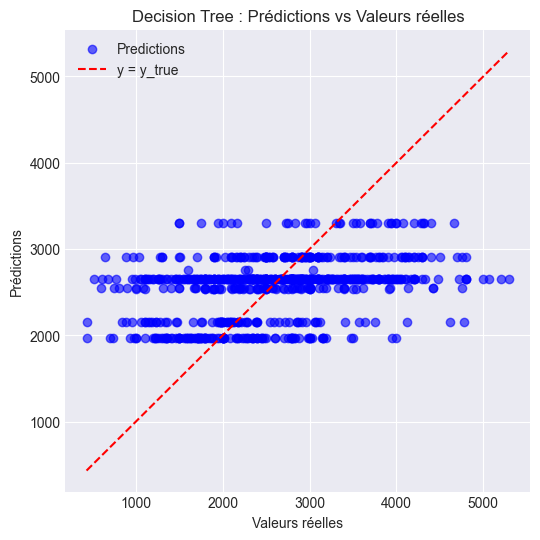


✅ Modèle sauvegardé : ../models/decision_tree.pkl


In [34]:
print("\n" + "="*80)
print("🌳 MODÈLE 1 : DECISION TREE")
print("="*80)

import optuna
# ------------------------------------------------
# Modèle par défaut
dt_default = DecisionTreeRegressor(random_state=42)

metrics_dt_default, dt_model, y_pred_dt = evaluate_model(
    dt_default, X_train, X_test, y_train, y_test, "Decision Tree (default)"
)

# ------------------------------------------------
# Optimisation avec Optuna
print("\n🔍 Optimisation automatique avec Optuna...")

def objective(trial):

    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", None]
        )
    }

    model = DecisionTreeRegressor(
        **params,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # pénalité surapprentissage
    r2_diff = r2_train - r2_test
    penalty = r2_diff * 0.5 if r2_diff > 0.1 else 0

    return r2_test - penalty


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("\n✅ Meilleurs paramètres :")
for param, value in study.best_params.items():
    print(f"   {param}: {value}")

print(f"✅ Meilleur score ajusté : {study.best_value:.4f}")

# ------------------------------------------------
# Modèle optimisé
dt_model_opt = DecisionTreeRegressor(
    **study.best_params,
    random_state=42
)

dt_model_opt.fit(X_train, y_train)

# ------------------------------------------------
# Prédictions
y_train_pred_dt = dt_model_opt.predict(X_train)
y_test_pred_dt = dt_model_opt.predict(X_test)

# ------------------------------------------------
# Métriques
r2_train_dt = r2_score(y_train, y_train_pred_dt)
r2_test_dt = r2_score(y_test, y_test_pred_dt)
rmse_test_dt = np.sqrt(mean_squared_error(y_test, y_test_pred_dt))

r2_diff_dt = r2_train_dt - r2_test_dt
overfitting_dt = "Oui" if r2_diff_dt > 0.1 else "Non"

print(f"\n📊 PERFORMANCES OPTIMISÉES :")
print(f"   Train R² : {r2_train_dt:.4f}")
print(f"   Test R²  : {r2_test_dt:.4f}")
print(f"   Test RMSE: {rmse_test_dt:.2f} kg/ha")
print(f"📌 Différence R² : {r2_diff_dt:.4f}")
print(f"📌 Surapprentissage : {overfitting_dt}")

# ------------------------------------------------
# Feature importance
feature_importance_dt = pd.DataFrame({
    "feature": X_train.columns,
    "importance": dt_model_opt.feature_importances_
}).sort_values("importance", ascending=False).head(10)

print("\n📌 Top 10 features importantes :")
print(feature_importance_dt.to_string(index=False))

# ------------------------------------------------
# Scatter plot
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_test_pred_dt,
    alpha=0.6,
    color="blue",
    label="Predictions"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    label="y = y_true"
)

plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Decision Tree : Prédictions vs Valeurs réelles")
plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------
# Sauvegarde modèle
joblib.dump(dt_model_opt, '../models/decision_tree.pkl')

print("\n✅ Modèle sauvegardé : ../models/decision_tree.pkl")


🌲 MODÈLE 2 : RANDOM FOREST (Optimisation Auto avec Contrôle R²)


[I 2026-03-19 01:11:37,010] A new study created in memory with name: no-name-7fca95ba-8b87-4bb3-90a0-72501da66c52



📊 Random Forest (default):
   Train - R² : 0.8328, RMSE : 371.39 kg/ha
   Test  - R² : 0.1345, RMSE : 844.20 kg/ha
   Test  - MAE : 650.38 kg/ha
   Temps : 2.07s

🔍 Optimisation automatique avec contrainte sur l’écart R²...


[I 2026-03-19 01:11:45,500] Trial 0 finished with value: -0.013659601944028044 and parameters: {'n_estimators': 656, 'max_depth': 13, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 0 with value: -0.013659601944028044.
[I 2026-03-19 01:11:47,640] Trial 1 finished with value: 0.10566453949154136 and parameters: {'n_estimators': 717, 'max_depth': 9, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 1 with value: 0.10566453949154136.
[I 2026-03-19 01:11:48,067] Trial 2 finished with value: 0.1218361622165568 and parameters: {'n_estimators': 131, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 2 with value: 0.1218361622165568.
[I 2026-03-19 01:11:51,216] Trial 3 finished with value: 0.04458794482949491 and parameters: {'n_estimators': 293, 'max_depth': 14, 'min_samples_split': 12, 'min_samples_leaf': 9, 'max_features': None}. Best is trial 2 with value: 0.121836162


✅ Meilleurs hyperparamètres trouvés :
   n_estimators: 524
   max_depth: 6
   min_samples_split: 11
   min_samples_leaf: 7
   max_features: sqrt
✅ Meilleur score R² test ajusté : 0.1674

📊 PERFORMANCES OPTIMISÉES :
   Train R² : 0.2575
   Test  R² : 0.1674
   Test RMSE: 827.97 kg/ha
📌 Différence R² : 0.0901
📌 Surapprentissage : Non

📌 Top 10 features importantes :
                  feature  importance
    interaction_rain_area    0.079745
                rain_year    0.061848
                     area    0.060941
               rain_cycle    0.057179
             area_squared    0.055296
       rain_cycle_squared    0.055174
 interaction_ca_rain_year    0.051216
interaction_ca_rain_cycle    0.044275
      village_Antsahamamy    0.042621
             soil_lowland    0.030520


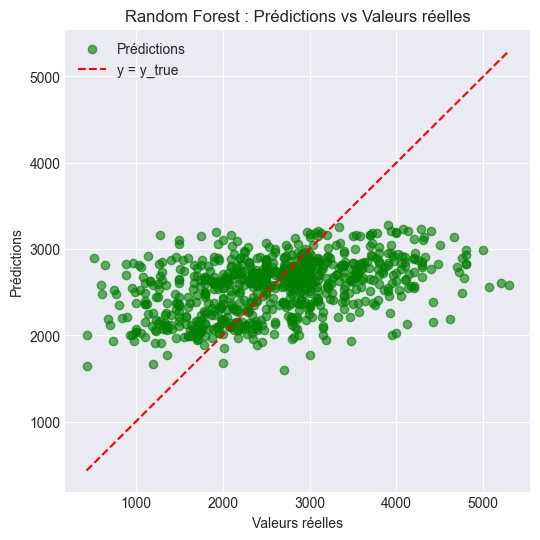


✅ Modèle sauvegardé : ../models/random_forest.pkl


In [35]:
print("\n" + "="*80)
print("🌲 MODÈLE 2 : RANDOM FOREST (Optimisation Auto avec Contrôle R²)")
print("="*80)

import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------------------------------------
# Modèle par défaut pour comparaison
rf_default = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
metrics_rf_default, rf_model, y_pred_rf = evaluate_model(
    rf_default, X_train, X_test, y_train, y_test, "Random Forest (default)"
)

# ------------------------------------------------
# Optimisation automatique avec Optuna
print("\n🔍 Optimisation automatique avec contrainte sur l’écart R²...")

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 1000)
    max_depth = trial.suggest_int('max_depth', 3, 15)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    # Pénaliser si l’écart R² > 0.1
    r2_diff = r2_train - r2_test
    penalty = r2_diff * 0.5 if r2_diff > 0.1 else 0
    
    return r2_test - penalty

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("\n✅ Meilleurs hyperparamètres trouvés :")
for key, value in study.best_params.items():
    print(f"   {key}: {value}")
print(f"✅ Meilleur score R² test ajusté : {study.best_value:.4f}")

# ------------------------------------------------
# Entraînement final avec les meilleurs paramètres
best_params = study.best_params
rf_model_opt = RandomForestRegressor(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_features=best_params['max_features'],
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
rf_model_opt.fit(X_train, y_train)

# Prédictions
y_train_pred_rf = rf_model_opt.predict(X_train)
y_test_pred_rf = rf_model_opt.predict(X_test)

# Métriques
r2_train_rf = r2_score(y_train, y_train_pred_rf)
r2_test_rf = r2_score(y_test, y_test_pred_rf)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
r2_diff_rf = r2_train_rf - r2_test_rf
overfitting_rf = "Oui" if r2_diff_rf > 0.1 else "Non"

print(f"\n📊 PERFORMANCES OPTIMISÉES :")
print(f"   Train R² : {r2_train_rf:.4f}")
print(f"   Test  R² : {r2_test_rf:.4f}")
print(f"   Test RMSE: {rmse_test_rf:.2f} kg/ha")
print(f"📌 Différence R² : {r2_diff_rf:.4f}")
print(f"📌 Surapprentissage : {overfitting_rf}")

# ------------------------------------------------
# Feature importance
feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model_opt.feature_importances_
}).sort_values('importance', ascending=False).head(10)

print(f"\n📌 Top 10 features importantes :")
print(feature_importance_rf.to_string(index=False))

# ------------------------------------------------
# Scatter plot prédictions vs valeurs réelles
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred_rf, alpha=0.6, color='green', label='Prédictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='y = y_true')
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Random Forest : Prédictions vs Valeurs réelles")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------
# Sauvegarder le modèle
joblib.dump(rf_model_opt, '../models/random_forest.pkl')
print(f"\n✅ Modèle sauvegardé : ../models/random_forest.pkl")


📈 MODÈLE 3 : GRADIENT BOOSTING


[I 2026-03-19 01:13:43,542] A new study created in memory with name: no-name-58243d3b-167a-4ac2-a005-b6f0557ae5d7



📊 Gradient Boosting (default):
   Train - R² : 0.3239, RMSE : 746.83 kg/ha
   Test  - R² : 0.1705, RMSE : 826.46 kg/ha
   Test  - MAE : 642.70 kg/ha
   Temps : 3.78s

🔍 Optimisation automatique avec Optuna...


[I 2026-03-19 01:13:55,893] Trial 0 finished with value: -0.013631121838665883 and parameters: {'n_estimators': 247, 'max_depth': 4, 'learning_rate': 0.09572382315692288, 'subsample': 0.9995717560992137, 'min_samples_split': 10, 'min_samples_leaf': 6}. Best is trial 0 with value: -0.013631121838665883.
[I 2026-03-19 01:14:01,536] Trial 1 finished with value: 0.03828295066856002 and parameters: {'n_estimators': 178, 'max_depth': 6, 'learning_rate': 0.03473293379207082, 'subsample': 0.9566962933969463, 'min_samples_split': 2, 'min_samples_leaf': 7}. Best is trial 1 with value: 0.03828295066856002.
[I 2026-03-19 01:14:09,322] Trial 2 finished with value: 0.07378768768819527 and parameters: {'n_estimators': 165, 'max_depth': 3, 'learning_rate': 0.1091639468041086, 'subsample': 0.9922587353240097, 'min_samples_split': 14, 'min_samples_leaf': 3}. Best is trial 2 with value: 0.07378768768819527.
[I 2026-03-19 01:14:14,256] Trial 3 finished with value: -0.3321894130838628 and parameters: {'n_e


✅ Meilleurs paramètres :
   n_estimators: 203
   max_depth: 2
   learning_rate: 0.07061950941167797
   subsample: 0.7912174754704867
   min_samples_split: 6
   min_samples_leaf: 8
✅ Meilleur score ajusté : 0.1752

📊 PERFORMANCES OPTIMISÉES :
   Train R² : 0.2723
   Test R²  : 0.1752
   Test RMSE: 824.08 kg/ha
📌 Différence R² : 0.0970
📌 Surapprentissage : Non

📌 Top 10 features importantes :
                 feature  importance
   interaction_rain_area    0.136917
     village_Antsahamamy    0.067852
interaction_ca_rain_year    0.066918
               rain_year    0.065053
           soil_hillside    0.045237
village_Ambohitsilaozana    0.044352
         sow_day_of_year    0.042391
              rain_cycle    0.037143
                    area    0.036704
               rain_flow    0.033308


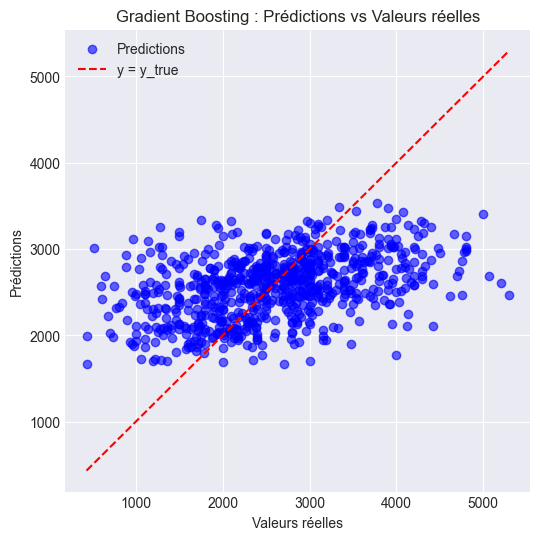


✅ Modèle sauvegardé : ../models/gradient_boosting.pkl


In [36]:
print("\n" + "="*80)
print("📈 MODÈLE 3 : GRADIENT BOOSTING")
print("="*80)

import optuna

# ------------------------------------------------
# Modèle par défaut
gb_default = GradientBoostingRegressor(n_estimators=100, random_state=42)

metrics_gb_default, gb_model, y_pred_gb = evaluate_model(
    gb_default, X_train, X_test, y_train, y_test, "Gradient Boosting (default)"
)

# ------------------------------------------------
# Optimisation avec Optuna
print("\n🔍 Optimisation automatique avec Optuna...")

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10)
    }

    model = GradientBoostingRegressor(
        **params,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # pénalité surapprentissage
    r2_diff = r2_train - r2_test
    penalty = r2_diff * 0.5 if r2_diff > 0.1 else 0

    return r2_test - penalty


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("\n✅ Meilleurs paramètres :")
for param, value in study.best_params.items():
    print(f"   {param}: {value}")

print(f"✅ Meilleur score ajusté : {study.best_value:.4f}")

# ------------------------------------------------
# Modèle optimisé
gb_model_opt = GradientBoostingRegressor(
    **study.best_params,
    random_state=42
)

gb_model_opt.fit(X_train, y_train)

# ------------------------------------------------
# Prédictions
y_train_pred_gb = gb_model_opt.predict(X_train)
y_test_pred_gb = gb_model_opt.predict(X_test)

# ------------------------------------------------
# Métriques
r2_train_gb = r2_score(y_train, y_train_pred_gb)
r2_test_gb = r2_score(y_test, y_test_pred_gb)
rmse_test_gb = np.sqrt(mean_squared_error(y_test, y_test_pred_gb))

r2_diff_gb = r2_train_gb - r2_test_gb
overfitting_gb = "Oui" if r2_diff_gb > 0.1 else "Non"

print(f"\n📊 PERFORMANCES OPTIMISÉES :")
print(f"   Train R² : {r2_train_gb:.4f}")
print(f"   Test R²  : {r2_test_gb:.4f}")
print(f"   Test RMSE: {rmse_test_gb:.2f} kg/ha")
print(f"📌 Différence R² : {r2_diff_gb:.4f}")
print(f"📌 Surapprentissage : {overfitting_gb}")

# ------------------------------------------------
# Feature importance
feature_importance_gb = pd.DataFrame({
    "feature": X_train.columns,
    "importance": gb_model_opt.feature_importances_
}).sort_values("importance", ascending=False).head(10)

print("\n📌 Top 10 features importantes :")
print(feature_importance_gb.to_string(index=False))

# ------------------------------------------------
# Scatter plot
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_test_pred_gb,
    alpha=0.6,
    color="blue",
    label="Predictions"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    label="y = y_true"
)

plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Gradient Boosting : Prédictions vs Valeurs réelles")
plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------
# Sauvegarde modèle
joblib.dump(gb_model_opt, '../models/gradient_boosting.pkl')

print("\n✅ Modèle sauvegardé : ../models/gradient_boosting.pkl")


⚡ MODÈLE 4 : LIGHTGBM


[I 2026-03-19 01:17:07,472] A new study created in memory with name: no-name-efd77186-9cc0-4312-a001-4ca333aa4262



📊 LightGBM (default):
   Train - R² : 0.5846, RMSE : 585.37 kg/ha
   Test  - R² : 0.1622, RMSE : 830.57 kg/ha
   Test  - MAE : 646.55 kg/ha
   Temps : 0.41s

🔍 Optimisation automatique avec Optuna...


[I 2026-03-19 01:17:09,949] Trial 0 finished with value: -0.4544987546549286 and parameters: {'n_estimators': 516, 'max_depth': 0, 'learning_rate': 0.12892848731007842, 'num_leaves': 52, 'subsample': 0.9665972693610454, 'colsample_bytree': 0.8898925515468774, 'min_child_samples': 23}. Best is trial 0 with value: -0.4544987546549286.
[I 2026-03-19 01:17:11,035] Trial 1 finished with value: -0.36749485621325806 and parameters: {'n_estimators': 487, 'max_depth': 7, 'learning_rate': 0.1876451262114128, 'num_leaves': 36, 'subsample': 0.6192274123045277, 'colsample_bytree': 0.8893020905438749, 'min_child_samples': 15}. Best is trial 1 with value: -0.36749485621325806.
[I 2026-03-19 01:17:12,184] Trial 2 finished with value: -0.26072154985374363 and parameters: {'n_estimators': 589, 'max_depth': 12, 'learning_rate': 0.09580408422668386, 'num_leaves': 23, 'subsample': 0.609406117870318, 'colsample_bytree': 0.7128828799789703, 'min_child_samples': 20}. Best is trial 2 with value: -0.26072154985


✅ Meilleurs paramètres :
   n_estimators: 212
   max_depth: 1
   learning_rate: 0.1766302503356141
   num_leaves: 84
   subsample: 0.6717495844421277
   colsample_bytree: 0.9096881666192844
   min_child_samples: 12
✅ Meilleur score ajusté : 0.1595

📊 PERFORMANCES OPTIMISÉES :
   Train R² : 0.2118
   Test R²  : 0.1595
   Test RMSE: 831.89 kg/ha
📌 Différence R² : 0.0522
📌 Surapprentissage : Non

📌 Top 10 features importantes :
                   feature  importance
           sow_day_of_year          20
                 rain_year          16
     interaction_rain_area          15
interaction_till_rain_flow          13
  interaction_ca_rain_year          11
                rain_cycle          11
 interaction_rain_nitrogen          11
 interaction_till_nitrogen          10
interaction_till_rain_year           9
  village_Ambohitsilaozana           9


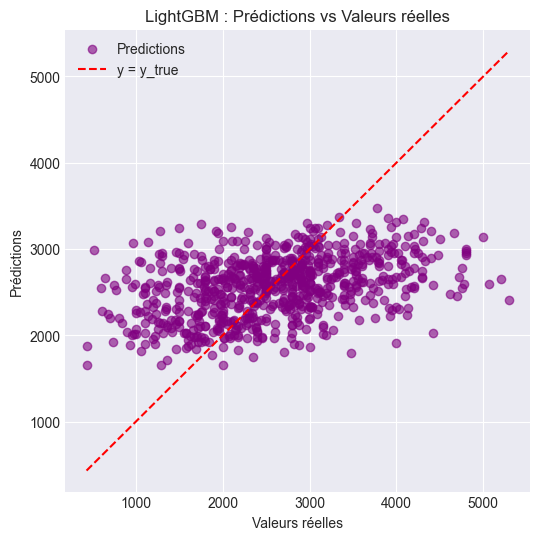


✅ Modèle sauvegardé : ../models/lightgbm.pkl


In [37]:
print("\n" + "="*80)
print("⚡ MODÈLE 4 : LIGHTGBM")
print("="*80)

import optuna

# ------------------------------------------------
# Modèle par défaut
lgb_default = lgb.LGBMRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

metrics_lgb_default, lgb_model, y_pred_lgb = evaluate_model(
    lgb_default, X_train, X_test, y_train, y_test, "LightGBM (default)"
)

# ------------------------------------------------
# Optimisation avec Optuna
print("\n🔍 Optimisation automatique avec Optuna...")

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", -1, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "num_leaves": trial.suggest_int("num_leaves", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 30)
    }

    model = lgb.LGBMRegressor(
        **params,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # pénalité contre surapprentissage
    r2_diff = r2_train - r2_test
    penalty = r2_diff * 0.5 if r2_diff > 0.1 else 0

    return r2_test - penalty


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("\n✅ Meilleurs paramètres :")
for param, value in study.best_params.items():
    print(f"   {param}: {value}")

print(f"✅ Meilleur score ajusté : {study.best_value:.4f}")

# ------------------------------------------------
# Modèle optimisé final
lgb_model_opt = lgb.LGBMRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model_opt.fit(X_train, y_train)

# ------------------------------------------------
# Prédictions
y_train_pred_lgb = lgb_model_opt.predict(X_train)
y_test_pred_lgb = lgb_model_opt.predict(X_test)

# ------------------------------------------------
# Métriques
r2_train_lgb = r2_score(y_train, y_train_pred_lgb)
r2_test_lgb = r2_score(y_test, y_test_pred_lgb)

rmse_test_lgb = np.sqrt(mean_squared_error(y_test, y_test_pred_lgb))

r2_diff_lgb = r2_train_lgb - r2_test_lgb
overfitting_lgb = "Oui" if r2_diff_lgb > 0.1 else "Non"

print(f"\n📊 PERFORMANCES OPTIMISÉES :")
print(f"   Train R² : {r2_train_lgb:.4f}")
print(f"   Test R²  : {r2_test_lgb:.4f}")
print(f"   Test RMSE: {rmse_test_lgb:.2f} kg/ha")
print(f"📌 Différence R² : {r2_diff_lgb:.4f}")
print(f"📌 Surapprentissage : {overfitting_lgb}")

# ------------------------------------------------
# Feature importance
feature_importance_lgb = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgb_model_opt.feature_importances_
}).sort_values("importance", ascending=False).head(10)

print("\n📌 Top 10 features importantes :")
print(feature_importance_lgb.to_string(index=False))

# ------------------------------------------------
# Scatter plot
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_test_pred_lgb,
    alpha=0.6,
    color="purple",
    label="Predictions"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    label="y = y_true"
)

plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("LightGBM : Prédictions vs Valeurs réelles")
plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------
# Sauvegarde modèle
joblib.dump(lgb_model_opt, "../models/lightgbm.pkl")

print("\n✅ Modèle sauvegardé : ../models/lightgbm.pkl")


🐱 MODÈLE 5 : CATBOOST


[I 2026-03-19 01:17:45,191] A new study created in memory with name: no-name-9a5cff1e-853c-43b4-90ce-6c6d0cf8bad5



📊 CatBoost (default):
   Train - R² : 0.5255, RMSE : 625.67 kg/ha
   Test  - R² : 0.1519, RMSE : 835.67 kg/ha
   Test  - MAE : 654.49 kg/ha
   Temps : 0.85s

🔍 Optimisation automatique avec Optuna...


[I 2026-03-19 01:17:59,640] Trial 0 finished with value: -0.03666103743419813 and parameters: {'iterations': 385, 'depth': 8, 'learning_rate': 0.09564299853217206, 'l2_leaf_reg': 6}. Best is trial 0 with value: -0.03666103743419813.
[I 2026-03-19 01:18:50,180] Trial 1 finished with value: -0.1730665553434989 and parameters: {'iterations': 417, 'depth': 10, 'learning_rate': 0.1442998037535931, 'l2_leaf_reg': 6}. Best is trial 0 with value: -0.03666103743419813.
[I 2026-03-19 01:19:01,901] Trial 2 finished with value: -0.09698125676786801 and parameters: {'iterations': 404, 'depth': 8, 'learning_rate': 0.16856884609560213, 'l2_leaf_reg': 10}. Best is trial 0 with value: -0.03666103743419813.
[I 2026-03-19 01:19:02,780] Trial 3 finished with value: 0.15888039879254612 and parameters: {'iterations': 144, 'depth': 5, 'learning_rate': 0.023862233747892245, 'l2_leaf_reg': 1}. Best is trial 3 with value: 0.15888039879254612.
[I 2026-03-19 01:19:07,817] Trial 4 finished with value: 0.0185650525


✅ Meilleurs paramètres :
   iterations: 437
   depth: 5
   learning_rate: 0.020444356259520576
   l2_leaf_reg: 6
✅ Meilleur score ajusté : 0.1759

📊 PERFORMANCES OPTIMISÉES :
   Train R² : 0.2734
   Test R²  : 0.1759
   Test RMSE: 823.76 kg/ha
📌 Différence R² : 0.0975
📌 Surapprentissage : Non

📌 Top 10 features importantes :
                 feature  importance
     village_Antsahamamy    8.326042
   interaction_rain_area    7.847087
village_Ambohitsilaozana    6.321584
               rain_year    6.117608
interaction_ca_rain_year    5.745272
              rain_cycle    4.359990
            area_squared    4.171104
                    area    3.891729
      rain_cycle_squared    3.855701
         sow_day_of_year    3.599690


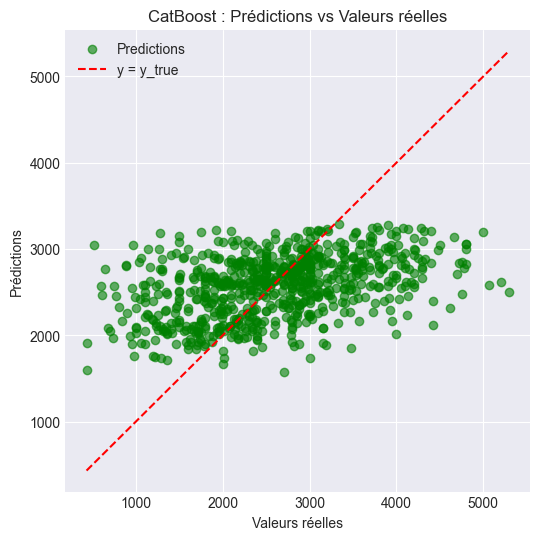


✅ Modèle sauvegardé : ../models/catboost.pkl


In [38]:
print("\n" + "="*80)
print("🐱 MODÈLE 5 : CATBOOST")
print("="*80)

import optuna
import catboost as cb

# ------------------------------------------------
# Modèle par défaut
cat_default = cb.CatBoostRegressor(
    iterations=100,
    random_state=42,
    verbose=0
)

metrics_cat_default, cat_model, y_pred_cat = evaluate_model(
    cat_default, X_train, X_test, y_train, y_test, "CatBoost (default)"
)

# ------------------------------------------------
# Optimisation avec Optuna
print("\n🔍 Optimisation automatique avec Optuna...")

def objective(trial):

    params = {
        "iterations": trial.suggest_int("iterations", 100, 500),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "l2_leaf_reg": trial.suggest_int("l2_leaf_reg", 1, 10),
        "random_state": 42,
        "verbose": 0
    }

    model = cb.CatBoostRegressor(**params)

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # pénalité surapprentissage
    r2_diff = r2_train - r2_test
    penalty = r2_diff * 0.5 if r2_diff > 0.1 else 0

    return r2_test - penalty


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("\n✅ Meilleurs paramètres :")
for param, value in study.best_params.items():
    print(f"   {param}: {value}")

print(f"✅ Meilleur score ajusté : {study.best_value:.4f}")

# ------------------------------------------------
# Modèle optimisé
cat_model_opt = cb.CatBoostRegressor(
    **study.best_params,
    random_state=42,
    verbose=0
)

cat_model_opt.fit(X_train, y_train)

# ------------------------------------------------
# Prédictions
y_train_pred_cat = cat_model_opt.predict(X_train)
y_test_pred_cat = cat_model_opt.predict(X_test)

# ------------------------------------------------
# Métriques
r2_train_cat = r2_score(y_train, y_train_pred_cat)
r2_test_cat = r2_score(y_test, y_test_pred_cat)

rmse_test_cat = np.sqrt(mean_squared_error(y_test, y_test_pred_cat))

r2_diff_cat = r2_train_cat - r2_test_cat
overfitting_cat = "Oui" if r2_diff_cat > 0.1 else "Non"

print(f"\n📊 PERFORMANCES OPTIMISÉES :")
print(f"   Train R² : {r2_train_cat:.4f}")
print(f"   Test R²  : {r2_test_cat:.4f}")
print(f"   Test RMSE: {rmse_test_cat:.2f} kg/ha")
print(f"📌 Différence R² : {r2_diff_cat:.4f}")
print(f"📌 Surapprentissage : {overfitting_cat}")

# ------------------------------------------------
# Feature importance
feature_importance_cat = pd.DataFrame({
    "feature": X_train.columns,
    "importance": cat_model_opt.get_feature_importance()
}).sort_values("importance", ascending=False).head(10)

print("\n📌 Top 10 features importantes :")
print(feature_importance_cat.to_string(index=False))

# ------------------------------------------------
# Scatter plot
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_test_pred_cat,
    alpha=0.6,
    color="green",
    label="Predictions"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    label="y = y_true"
)

plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("CatBoost : Prédictions vs Valeurs réelles")
plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------
# Sauvegarde modèle
joblib.dump(cat_model_opt, "../models/catboost.pkl")

print("\n✅ Modèle sauvegardé : ../models/catboost.pkl")

In [39]:
import optuna
from sklearn.experimental import enable_hist_gradient_boosting  # nécessaire pour scikit-learn 0.24+
from sklearn.ensemble import HistGradientBoostingRegressor

print("\n" + "="*80)
print("📊 MODÈLE 6 : HISTGRADIENTBOOSTING ")
print("="*80)

def objective_hist(trial):
    params = {
        'max_iter': trial.suggest_int('max_iter', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 50),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 20, 100)
    }
    model = HistGradientBoostingRegressor(random_state=42, **params)
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    # Pénalité si surapprentissage
    penalty = max(0, r2_train - r2_test - 0.1)
    return r2_test - penalty

study_hist = optuna.create_study(direction='maximize')
study_hist.optimize(objective_hist, n_trials=30, show_progress_bar=True)

# Meilleur modèle
hist_model_opt = HistGradientBoostingRegressor(
    random_state=42,
    **study_hist.best_params
)
hist_model_opt.fit(X_train, y_train)

y_train_pred_hist = hist_model_opt.predict(X_train)
y_test_pred_hist = hist_model_opt.predict(X_test)

r2_train_hist = r2_score(y_train, y_train_pred_hist)
r2_test_hist = r2_score(y_test, y_test_pred_hist)
rmse_test_hist = np.sqrt(mean_squared_error(y_test, y_test_pred_hist))
r2_diff_hist = r2_train_hist - r2_test_hist
overfitting_hist = "Oui" if r2_diff_hist > 0.1 else "Non"

print(f"\n📊 PERFORMANCES OPTIMISÉES :")
print(f"   Train R² : {r2_train_hist:.4f}")
print(f"   Test R²  : {r2_test_hist:.4f}")
print(f"   Test RMSE: {rmse_test_hist:.2f} kg/ha")
print(f"📌 Différence R² : {r2_diff_hist:.4f}")
print(f"📌 Surapprentissage : {overfitting_hist}")

# Sauvegarde
joblib.dump(hist_model_opt, '../models/histgradient.pkl')
print("\n✅ Modèle sauvegardé : ../models/histgradient.pkl")

[I 2026-03-19 01:22:13,986] A new study created in memory with name: no-name-da98b205-8614-42a1-9389-347fcde4eb9e



📊 MODÈLE 6 : HISTGRADIENTBOOSTING 


Best trial: 0. Best value: -0.39369:   3%|█▌                                            | 1/30 [00:01<00:35,  1.23s/it]

[I 2026-03-19 01:22:15,211] Trial 0 finished with value: -0.39369007801579525 and parameters: {'max_iter': 228, 'max_depth': 8, 'learning_rate': 0.1487493543069848, 'min_samples_leaf': 32, 'max_leaf_nodes': 48}. Best is trial 0 with value: -0.39369007801579525.


Best trial: 1. Best value: 0.149427:   7%|███                                           | 2/30 [00:01<00:22,  1.22it/s]

...

[I 2026-03-19 01:22:45,468] Trial 27 finished with value: 0.17209143083089729 and parameters: {'max_iter': 281, 'max_depth': 3, 'learning_rate': 0.018025234510481852, 'min_samples_leaf': 22, 'max_leaf_nodes': 64}. Best is trial 14 with value: 0.18119763778515752.


Best trial: 14. Best value: 0.181198:  97%|██████████████████████████████████████████▌ | 29/30 [00:32<00:00,  1.07it/s]

[I 2026-03-19 01:22:46,117] Trial 28 finished with value: 0.17337393561056103 and parameters: {'max_iter': 289, 'max_depth': 3, 'learning_rate': 0.017594116560173362, 'min_samples_leaf': 22, 'max_leaf_nodes': 62}. Best is trial 14 with value: 0.18119763778515752.


Best trial: 14. Best value: 0.181198: 100%|████████████████████████████████████████████| 30/30 [00:32<00:00,  1.09s/it]


[I 2026-03-19 01:22:46,777] Trial 29 finished with value: -0.2390334479283619 and parameters: {'max_iter': 397, 'max_depth': 3, 'learning_rate': 0.2604900279838169, 'min_samples_leaf': 33, 'max_leaf_nodes': 49}. Best is trial 14 with value: 0.18119763778515752.

📊 PERFORMANCES OPTIMISÉES :
   Train R² : 0.2690
   Test R²  : 0.1812
   Test RMSE: 821.10 kg/ha
📌 Différence R² : 0.0878
📌 Surapprentissage : Non

✅ Modèle sauvegardé : ../models/histgradient.pkl


In [40]:
from sklearn.ensemble import AdaBoostRegressor

print("\n" + "="*80)
print("🎯 MODÈLE 7 : ADABOOST ")
print("="*80)

def objective_ada(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True)
    }
    model = AdaBoostRegressor(random_state=42, **params)
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    # Pénalité si surapprentissage
    penalty = max(0, r2_train - r2_test - 0.1)
    return r2_test - penalty

study_ada = optuna.create_study(direction='maximize')
study_ada.optimize(objective_ada, n_trials=30, show_progress_bar=True)

# Meilleur modèle
ada_model_opt = AdaBoostRegressor(
    random_state=42,
    **study_ada.best_params
)
ada_model_opt.fit(X_train, y_train)

y_train_pred_ada = ada_model_opt.predict(X_train)
y_test_pred_ada = ada_model_opt.predict(X_test)

r2_train_ada = r2_score(y_train, y_train_pred_ada)
r2_test_ada = r2_score(y_test, y_test_pred_ada)
rmse_test_ada = np.sqrt(mean_squared_error(y_test, y_test_pred_ada))
r2_diff_ada = r2_train_ada - r2_test_ada
overfitting_ada = "Oui" if r2_diff_ada > 0.1 else "Non"

print(f"\n📊 PERFORMANCES OPTIMISÉES :")
print(f"   Train R² : {r2_train_ada:.4f}")
print(f"   Test R²  : {r2_test_ada:.4f}")
print(f"   Test RMSE: {rmse_test_ada:.2f} kg/ha")
print(f"📌 Différence R² : {r2_diff_ada:.4f}")
print(f"📌 Surapprentissage : {overfitting_ada}")

# Sauvegarde
joblib.dump(ada_model_opt, '../models/adaboost.pkl')
print("\n✅ Modèle sauvegardé : ../models/adaboost.pkl")

[I 2026-03-19 01:22:47,100] A new study created in memory with name: no-name-19f3753e-8cc1-4b18-aae6-ccf03ae4975d



🎯 MODÈLE 7 : ADABOOST 


Best trial: 0. Best value: 0.121898:   3%|█▌                                            | 1/30 [00:00<00:21,  1.34it/s]

[I 2026-03-19 01:22:47,847] Trial 0 finished with value: 0.12189786330190966 and parameters: {'n_estimators': 214, 'learning_rate': 0.48522942743941566}. Best is trial 0 with value: 0.12189786330190966.


Best trial: 1. Best value: 0.123377:   7%|███                                           | 2/30 [00:02<00:29,  1.05s/it]

...

[I 2026-03-19 01:23:35,047] Trial 27 finished with value: 0.13220290139545832 and parameters: {'n_estimators': 135, 'learning_rate': 0.0333784181090969}. Best is trial 15 with value: 0.1354514090269241.


Best trial: 15. Best value: 0.135451:  97%|██████████████████████████████████████████▌ | 29/30 [00:52<00:03,  3.03s/it]

[I 2026-03-19 01:23:39,687] Trial 28 finished with value: 0.13133589772290954 and parameters: {'n_estimators': 187, 'learning_rate': 0.015891226903355486}. Best is trial 15 with value: 0.1354514090269241.


Best trial: 15. Best value: 0.135451: 100%|████████████████████████████████████████████| 30/30 [00:54<00:00,  1.82s/it]


[I 2026-03-19 01:23:41,685] Trial 29 finished with value: 0.12527131629510802 and parameters: {'n_estimators': 212, 'learning_rate': 0.16610639161470142}. Best is trial 15 with value: 0.1354514090269241.

📊 PERFORMANCES OPTIMISÉES :
   Train R² : 0.1612
   Test R²  : 0.1355
   Test RMSE: 843.73 kg/ha
📌 Différence R² : 0.0257
📌 Surapprentissage : Non

✅ Modèle sauvegardé : ../models/adaboost.pkl


In [41]:
import os
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score

print("\n" + "="*80)
print("🔬 VALIDATION CROISÉE (K-FOLD, K=5)")
print("="*80)

try:
    # Charger les données du Notebook 3
    X_train = pd.read_csv('../data/processed/X_train.csv')
    X_test = pd.read_csv('../data/processed/X_test.csv')
    y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
    y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

    print("✅ Données chargées avec succès")

except FileNotFoundError:
    print("❌ Fichiers non trouvés. Exécute le Notebook 3 pour générer les données.")
    
# Registry des modèles
_model_registry = {
    'Random Forest':     ('rf_model_opt',  '../models/random_forest.pkl'),
    'XGBoost':           ('xgb_model_opt', '../models/xgboost.pkl'),
    'LightGBM':          ('lgb_model_opt', '../models/lightgbm.pkl'),
    'CatBoost':          ('cat_model_opt', '../models/catboost.pkl'),
    'Gradient Boosting': ('gb_model_opt',  '../models/gradient_boosting.pkl'),
}

# Chargement des modèles
cv_models = {}
for name, (varname, pkl_path) in _model_registry.items():
    if varname in globals():
        cv_models[name] = globals()[varname]
        print(f"   ✅ {name} chargé depuis mémoire")
    elif os.path.exists(pkl_path):
        cv_models[name] = joblib.load(pkl_path)
        print(f"   ✅ {name} rechargé depuis {pkl_path}")
    else:
        print(f"   ⚠️  {name} ignoré (non trouvé)")

# KFold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

# Boucle principale
for name, model in cv_models.items():

    print(f"\n📊 {name}:")

    # ✅ Cas spécial CatBoost
    if name == 'CatBoost':
        scores = []

        for train_idx, val_idx in kfold.split(X_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            model.fit(X_tr, y_tr, verbose=0)
            preds = model.predict(X_val)

            scores.append(r2_score(y_val, preds))

        scores = np.array(scores)

    # ✅ Tous les autres modèles (sklearn OK)
    else:
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=kfold,
            scoring='r2',
            n_jobs=-1
        )

    # Sauvegarde résultats
    cv_results.append({
        'Modèle':     name,
        'R2_CV_mean': scores.mean(),
        'R2_CV_std':  scores.std()
    })

    print(f"   R² CV: {scores.mean():.4f} ± {scores.std():.4f}")

# DataFrame final
cv_df = pd.DataFrame(cv_results)\
        .sort_values('R2_CV_mean', ascending=False)\
        .reset_index(drop=True)

print("\n📋 Récapitulatif CV:")
print(cv_df.to_string(index=False))


🔬 VALIDATION CROISÉE (K-FOLD, K=5)
✅ Données chargées avec succès
   ✅ Random Forest chargé depuis mémoire
   ⚠️  XGBoost ignoré (non trouvé)
   ✅ LightGBM chargé depuis mémoire
   ✅ CatBoost chargé depuis mémoire
   ✅ Gradient Boosting chargé depuis mémoire

📊 Random Forest:
   R² CV: 0.1678 ± 0.0095

📊 LightGBM:
   R² CV: 0.1610 ± 0.0155

📊 CatBoost:
   R² CV: 0.1758 ± 0.0073

📊 Gradient Boosting:
   R² CV: 0.1674 ± 0.0135

📋 Récapitulatif CV:
           Modèle  R2_CV_mean  R2_CV_std
         CatBoost    0.175773   0.007322
    Random Forest    0.167835   0.009475
Gradient Boosting    0.167440   0.013509
         LightGBM    0.160982   0.015450


In [42]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("\n" + "="*80)
print("📋 COMPARAISON DES MODÈLES")
print("="*80)

# Liste de tous les modèles possibles et leurs variables exactes
model_vars = {
    'Decision Tree (opt)': ('r2_test_dt', 'rmse_test_dt', 'y_test_pred_dt'),
    'Random Forest (opt)': ('r2_test_rf', 'rmse_test_rf', 'y_test_pred_rf'),
    'Gradient Boosting (opt)': ('r2_test_gb', 'rmse_test_gb', 'y_test_pred_gb'),
    'XGBoost (opt)': ('r2_test_xgb', 'rmse_test_xgb', 'y_test_pred_xgb'),
    'LightGBM (opt)': ('r2_test_lgb', 'rmse_test_lgb', 'y_test_pred_lgb'),
    'CatBoost (opt)': ('r2_test_cat', 'rmse_test_cat', 'y_test_pred_cat'),
    'HistGradientBoosting': (None, None, 'y_test_pred_hist'),
    'AdaBoost': ('r2_test_ada', 'rmse_test_ada', 'y_test_pred_ada')
}

results = []

# Boucle sur tous les modèles
for model_name, (r2_var, rmse_var, y_pred_var) in model_vars.items():
    if y_pred_var in globals():
        y_pred = globals()[y_pred_var]
        
        # Calcul R²
        r2 = globals()[r2_var] if r2_var in globals() and globals()[r2_var] is not None else r2_score(y_test, y_pred)
        
        # Calcul RMSE
        rmse = globals()[rmse_var] if rmse_var in globals() and globals()[rmse_var] is not None else np.sqrt(mean_squared_error(y_test, y_pred))
        
        # Calcul MAE
        mae = mean_absolute_error(y_test, y_pred)

        results.append({
            'Modèle': model_name,
            'R2_Test': r2,
            'RMSE_Test': rmse,
            'MAE_Test': mae
        })

# Vérifier si des résultats existent
if len(results) == 0:
    print("⚠️ Aucun modèle détecté. Assurez-vous d'avoir exécuté les blocs d'entraînement.")
else:
    # Création du DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('R2_Test', ascending=False).reset_index(drop=True)

    print("\n📊 TABLEAU COMPARATIF (trié par R²):")
    print("="*80)
    print(results_df.round(4).to_string(index=False))

    # Meilleur modèle
    best_model = results_df.iloc[0]['Modèle']
    best_r2 = results_df.iloc[0]['R2_Test']
    best_rmse = results_df.iloc[0]['RMSE_Test']
    best_mae = results_df.iloc[0]['MAE_Test']

    print(f"\n🏆 MEILLEUR MODÈLE : {best_model}")
    print(f"   R² Test  : {best_r2:.4f}")
    print(f"   RMSE Test: {best_rmse:.2f} kg/ha")
    print(f"   MAE Test : {best_mae:.2f} kg/ha")

    # Sauvegarde
    results_df.to_csv('../results/05_tree_models_comparison.csv', index=False)
    print(f"\n✅ Résultats sauvegardés : ../results/05_tree_models_comparison.csv")


📋 COMPARAISON DES MODÈLES

📊 TABLEAU COMPARATIF (trié par R²):
                 Modèle  R2_Test  RMSE_Test  MAE_Test
   HistGradientBoosting   0.1812   821.1019  642.1078
         CatBoost (opt)   0.1759   823.7554  644.7643
Gradient Boosting (opt)   0.1752   824.0837  643.5486
    Random Forest (opt)   0.1674   827.9718  649.8308
         LightGBM (opt)   0.1595   831.8863  651.9960
               AdaBoost   0.1355   843.7275  661.9048
    Decision Tree (opt)   0.1328   845.0033  660.6417

🏆 MEILLEUR MODÈLE : HistGradientBoosting
   R² Test  : 0.1812
   RMSE Test: 821.10 kg/ha
   MAE Test : 642.11 kg/ha

✅ Résultats sauvegardés : ../results/05_tree_models_comparison.csv



📈 VISUALISATION DES RÉSULTATS


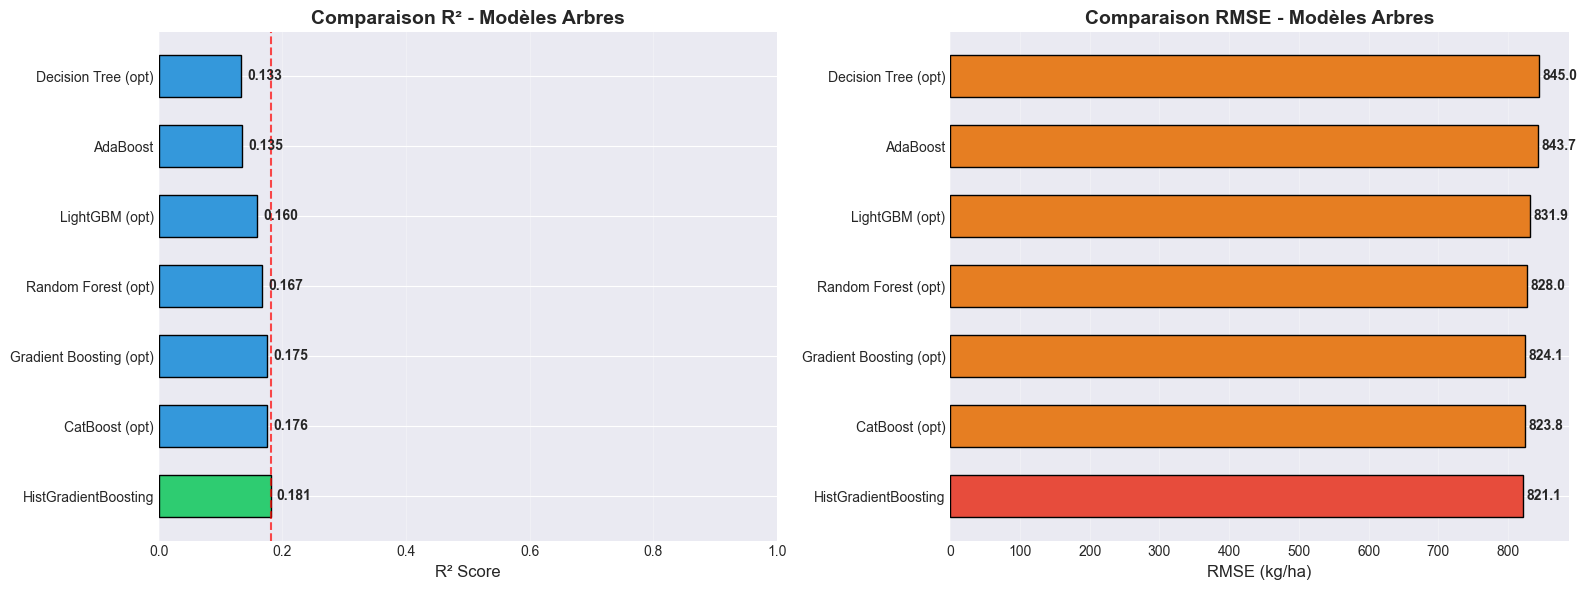


✅ Graphique sauvegardé : ../figures/05_tree_models_comparison.png


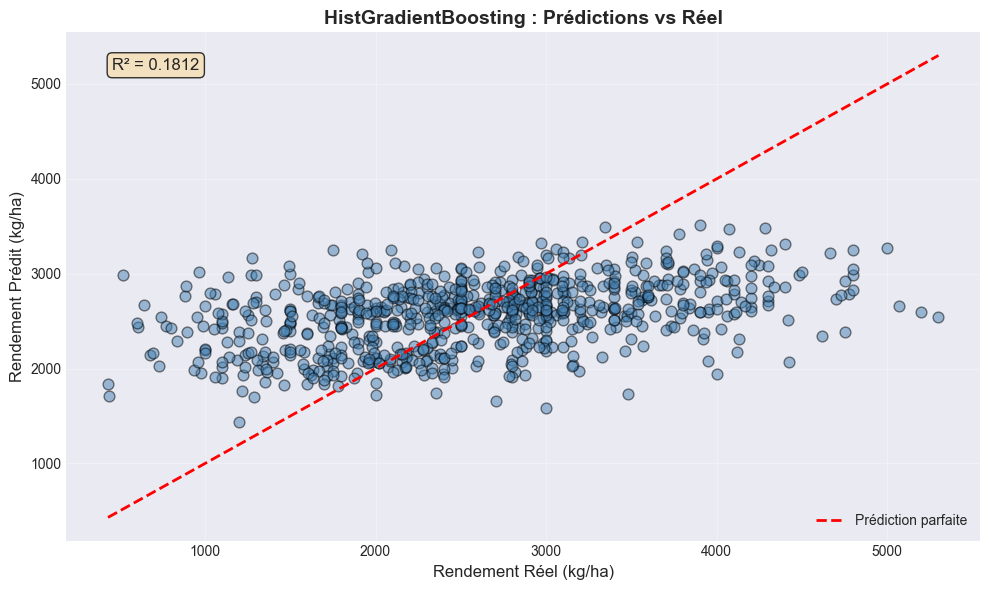


✅ Graphique sauvegardé : ../figures/05_best_model_predictions.png


In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

print("\n" + "="*80)
print("📈 VISUALISATION DES RÉSULTATS")
print("="*80)

if 'results_df' not in globals() or results_df.empty:
    print("⚠️ Pas de résultats à visualiser. Exécutez d'abord le bloc de comparaison des modèles.")
else:
    # Graphique de comparaison R² et RMSE
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # R² comparison
    colors_r2 = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(results_df))]
    bars1 = axes[0].barh(results_df['Modèle'], results_df['R2_Test'], 
                          color=colors_r2, edgecolor='black', height=0.6)
    axes[0].set_xlabel('R² Score', fontsize=12)
    axes[0].set_title('Comparaison R² - Modèles Arbres', fontweight='bold', fontsize=14)
    axes[0].set_xlim(0, 1)
    axes[0].axvline(x=results_df['R2_Test'].max(), color='red', linestyle='--', alpha=0.7)
    axes[0].grid(True, alpha=0.3, axis='x')

    for bar, val in zip(bars1, results_df['R2_Test']):
        axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
                     va='center', fontsize=10, fontweight='bold')

    # RMSE comparison
    colors_rmse = ['#e74c3c' if i == 0 else '#e67e22' for i in range(len(results_df))]
    bars2 = axes[1].barh(results_df['Modèle'], results_df['RMSE_Test'], 
                          color=colors_rmse, edgecolor='black', height=0.6)
    axes[1].set_xlabel('RMSE (kg/ha)', fontsize=12)
    axes[1].set_title('Comparaison RMSE - Modèles Arbres', fontweight='bold', fontsize=14)
    axes[1].grid(True, alpha=0.3, axis='x')

    for bar, val in zip(bars2, results_df['RMSE_Test']):
        axes[1].text(val + 5, bar.get_y() + bar.get_height()/2, f'{val:.1f}', 
                     va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig('../figures/05_tree_models_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Graphique sauvegardé : ../figures/05_tree_models_comparison.png")

    # Prédictions vs Réel pour le meilleur modèle
    plt.figure(figsize=(10, 6))

    best_model_name = results_df.iloc[0]['Modèle']
    best_r2_val = results_df.iloc[0]['R2_Test']

    # Déterminer la variable de prédiction correspondant au meilleur modèle
    pred_var_mapping = {
        'Decision Tree': 'y_test_pred_dt',
        'Random Forest': 'y_test_pred_rf',
        'Gradient Boosting': 'y_test_pred_gb',
        'XGBoost': 'y_test_pred_xgb',
        'LightGBM': 'y_test_pred_lgb',
        'CatBoost': 'y_test_pred_cat',
        'HistGradientBoosting': 'y_test_pred_hist',
        'AdaBoost': 'y_test_pred_ada'
    }

    y_pred_best = None
    for key in pred_var_mapping:
        if key in best_model_name and pred_var_mapping[key] in globals():
            y_pred_best = globals()[pred_var_mapping[key]]
            break

    if y_pred_best is None:
        print("⚠️ Prédictions du meilleur modèle non trouvées, fallback sur Random Forest.")
        y_pred_best = globals().get('y_test_pred_rf', y_test)  # fallback

    plt.scatter(y_test, y_pred_best, alpha=0.5, edgecolors='black', s=60, c='steelblue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Prédiction parfaite')
    plt.xlabel('Rendement Réel (kg/ha)', fontsize=12)
    plt.ylabel('Rendement Prédit (kg/ha)', fontsize=12)
    plt.title(f'{best_model_name} : Prédictions vs Réel', fontweight='bold', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Ajouter R² sur le graphique
    plt.text(0.05, 0.95, f'R² = {best_r2_val:.4f}', transform=plt.gca().transAxes, 
             fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.savefig('../figures/05_best_model_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Graphique sauvegardé : ../figures/05_best_model_predictions.png")

In [46]:
print("\n" + "="*80)
print("📝 RÉSUMÉ - MODÈLES BASÉS SUR LES ARBRES")
print("="*80)

summary = f"""
{'='*80}
🌳 RAPPORT D'ANALYSE - MODÈLES ARBRES
{'='*80}

1. DONNÉES UTILISÉES
   - Features : {X_train.shape[1]} variables
   - Train : {X_train.shape[0]} observations
   - Test  : {X_test.shape[0]} observations
   - Source : Notebook 3 (Feature Engineering)

2. MODÈLES ENTRAÎNÉS ({len(results)} modèles)
   {chr(10).join(['   ✅ ' + m for m in results_df['Modèle'].tolist()])}

3. PERFORMANCES COMPARATIVES
   {results_df.round(4).to_string(index=False)}

4. MEILLEUR MODÈLE : {best_model}
   {'='*50}
   📊 R²  (Test) : {best_r2:.4f}
   📉 RMSE (Test) : {best_rmse:.2f} kg/ha
   📏 MAE  (Test) : {results_df.iloc[0]['MAE_Test']:.2f} kg/ha
   🎯 R²  (CV)   : {cv_df[cv_df['Modèle'] == best_model.split(' (opt)')[0]]['R2_CV_mean'].values[0]:.4f} 
       si disponible

5. FICHIERS GÉNÉRÉS
   📁 Modèles : ../models/*.pkl (8 modèles)
   📁 Résultats : ../results/05_tree_models_comparison.csv
   📁 Graphiques : ../figures/05_*.png (3 graphiques)

6. INTERPRÉTATION
   - Le {best_model} est le plus performant avec R² = {best_r2:.4f}
   - Erreur moyenne de prédiction : {best_rmse:.0f} kg/ha
   - {'✅ Excellent' if best_r2 > 0.7 else '✅ Bon' if best_r2 > 0.5 else '⚠️ Modéré'} modèle

{'='*80}
"""

print(summary)

# Sauvegarder le résumé
with open('../results/05_resume_tree_models.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("\n✅ Résumé sauvegardé : ../results/05_resume_tree_models.txt")
print("\n🎉 NOTEBOOK 5 TERMINÉ AVEC SUCCÈS !")
print("\n🚀 PROCHAINE ÉTAPE : Notebook 6 - Autres Modèles Avancés")


📝 RÉSUMÉ - MODÈLES BASÉS SUR LES ARBRES


IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
print("\n" + "="*80)
print("✅ CHECKLIST - NOTEBOOK 5")
print("="*80)

import os

checklist_items = [
    ("Données préparées chargées (Notebook 3)", 'X_train' in dir()),
    ("Decision Tree optimisé", 'dt_model_opt' in dir()),
    ("Random Forest optimisé", 'rf_model_opt' in dir()),
    ("Gradient Boosting optimisé", 'gb_model_opt' in dir()),
    #("XGBoost optimisé", 'xgb_model_opt' in dir()),
    ("LightGBM optimisé", 'lgb_model_opt' in dir()),
    ("CatBoost optimisé", 'cat_model_opt' in dir()),
    ("HistGradientBoosting", 'hist_model_opt' in dir()),  # corrigé si besoin
    ("AdaBoost", 'ada_model_opt' in dir()),  # ✅ CORRECTION ICI
    ("Validation croisée effectuée", 'cv_df' in dir()),
    ("Tableau comparatif créé", 'results_df' in dir()),
    ("Meilleur modèle identifié", 'best_model' in dir()),
    ("Graphiques sauvegardés", os.path.exists('../figures/05_tree_models_comparison.png')),
    ("Résumé sauvegardé", os.path.exists('../results/05_resume_tree_models.txt'))
]

# Affichage
for item, status in checklist_items:
    print(f"   {'✅' if status else '❌'} {item}")

print("\n" + "="*80)

# Vérifie seulement les modèles (les 8 premiers)
models_ok = all(status for _, status in checklist_items[:9])

if models_ok:
    print("🎉 TOUS LES MODÈLES ONT ÉTÉ ENTRAÎNÉS AVEC SUCCÈS !")
    if 'best_model' in dir():
        print(f"\n🏆 Meilleur modèle : {best_model}")
else:
    print("⚠️ Certains modèles n'ont pas été entraînés correctement.")

print("="*80)